## Librerías.

In [1]:
import sys
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial'
if project_path not in sys.path:
    sys.path.append(project_path)

Mounted at /content/drive


## Fine tunning.

In [ ]:
# Generadores.
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2)

# Generador de entrenamiento.
train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='training',
    shuffle=True)

# Generador de validación.
valid_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='validation',
    shuffle=False)

In [42]:
# Cargamos modelo.
ruta_fase1 = os.path.join(project_path, 'models/mi_reconocedor.h5')


# Buscamos el extractor de características.
feature_extractor = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Sequential):
        feature_extractor = layer
        break

if feature_extractor:
    print(f"Extractor base encontrado: {feature_extractor.name}")
    feature_extractor.trainable = True

    # Entrenamos solo las últimas capas.
    capas_a_entrenar = 3
    for layer in feature_extractor.layers[:-capas_a_entrenar]:
        layer.trainable = False

Extractor base encontrado: sequential_6


In [46]:
# Recompilamos.
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy'])

ruta_final_refinado = os.path.join(project_path, 'models/mi_reconocedor_refinado_2.h5')

checkpoint_fino = ModelCheckpoint(
    filepath=ruta_final_refinado,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1)

early_stop_fino = EarlyStopping(
    monitor='val_accuracy',
    patience=30,
    restore_best_weights=True)

In [47]:
# Entrenamos.
history_fine = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=100,
    callbacks=[checkpoint_fino, early_stop_fino])

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8627 - loss: 3.7173
Epoch 1: val_accuracy improved from -inf to 0.66667, saving model to /content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/models/mi_reconocedor_refinado_2.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 674ms/step - accuracy: 0.8585 - loss: 3.7168 - val_accuracy: 0.6667 - val_loss: 3.7235
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7409 - loss: 3.6997
Epoch 2: val_accuracy improved from 0.66667 to 0.72222, saving model to /content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/models/mi_reconocedor_refinado_2.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 331ms/step - accuracy: 0.7429 - loss: 3.6980 - val_accuracy: 0.7222 - val_loss: 3.6698
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.7156 - loss: 3.6388
Epoch 3: val_accuracy did not improve from 0.72222
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 275ms/step - accuracy: 0.7188 - loss: 3.6378 - val_accuracy: 0.6667 - val_loss: 3.6309
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.6751 - loss: 3.6008
Epoch 4: val_accuracy did not improve from 0.72222
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - accuracy: 0.6819 - loss: 3.5991 - val_accuracy: 0.7222 - val_loss: 3.6020
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7976 - loss: 3.5544
Epoch 5: val_accuracy did not improve from 0.72222
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 261ms/step - accuracy: 0.7968 - loss: 3.5538 - val_accuracy: 0.7222 - val_loss: 3.5559
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8738 - loss: 3.4985
Epoch 6: val_accuracy did not i

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 414ms/step - accuracy: 0.7311 - loss: 3.4472 - val_accuracy: 0.7778 - val_loss: 3.4366
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.7463 - loss: 3.3954
Epoch 9: val_accuracy improved from 0.77778 to 0.83333, saving model to /content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/models/mi_reconocedor_refinado_2.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 295ms/step - accuracy: 0.7502 - loss: 3.3950 - val_accuracy: 0.8333 - val_loss: 3.4056
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.8498 - loss: 3.3490
Epoch 10: val_accuracy did not improve from 0.83333
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - accuracy: 0.8479 - loss: 3.3487 - val_accuracy: 0.7778 - val_loss: 3.3745
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8440 - loss: 3.3230
Epoch 11: val_accuracy did not improve from 0.83333
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 292ms/step - accuracy: 0.8426 - loss: 3.3221 - val_accuracy: 0.6667 - val_loss: 3.3554
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.7355 - loss: 3.3058
Epoch 12: val_accuracy did not improve from 0.83333
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 397ms/step - accuracy: 0.7428 - loss: 3.3032 - val_accuracy: 0.6111 - val_loss: 3.3218
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8333 - loss: 3.2308
Epoch 13: val_accuracy d

In [48]:
def graficar_entrenamiento(historia):
    acc = historia.history['accuracy']
    val_acc = historia.history['val_accuracy']
    loss = historia.history['loss']
    val_loss = historia.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Presición.
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='green')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red')
    plt.legend(loc='lower right')
    plt.title('Precisión (Accuracy)')
    plt.grid(True)
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')

    # Costo.
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='green')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
    plt.legend(loc='upper right')
    plt.title('Costo (Loss)')
    plt.grid(True)
    plt.xlabel('Épocas')
    plt.ylabel('Loss')

    plt.show()

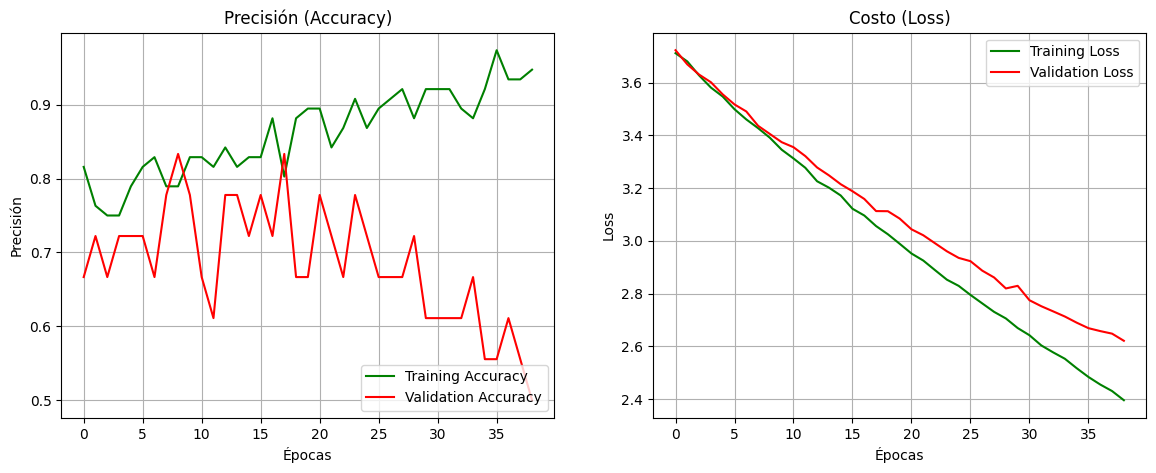

In [49]:
# Graficamos.
graficar_entrenamiento(history_fine)